# Get Packages

In [3]:
import yfinance as yf
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Read in needed packages

In [53]:
# We use SPY as our equity index and TLT as our bond index
tickers = ["SPY", "TLT"]

# Read in data from yFinance (TLT starts in 2002)
data = (
    yf.download(tickers, start="2002-07-30", end="2025-10-05", auto_adjust=True)["Close"]
    .dropna()
)

# Convert to Polars
df = pl.from_pandas(data.reset_index())
df = df.rename({"Date": "date", "SPY": "SPY", "TLT": "TLT"}).sort("date")

# Compute daily returns
returns = df.with_columns([
    (pl.col("SPY") / pl.col("SPY").shift(1) - 1).alias("r_spy"),
    (pl.col("TLT") / pl.col("TLT").shift(1) - 1).alias("r_tlt"),
]).drop_nulls()

returns

[*********************100%***********************]  2 of 2 completed


date,SPY,TLT,r_spy,r_tlt
datetime[ns],f64,f64,f64,f64
2002-07-31 00:00:00,59.320873,37.514782,0.002418,0.012389
2002-08-01 00:00:00,57.772182,37.728451,-0.026107,0.005696
2002-08-02 00:00:00,56.477188,38.114799,-0.022416,0.01024
2002-08-05 00:00:00,54.512001,38.283005,-0.034796,0.004413
2002-08-06 00:00:00,56.347038,37.955711,0.033663,-0.008549
…,…,…,…,…
2025-09-29 00:00:00,663.679993,89.319092,0.00281,0.008211
2025-09-30 00:00:00,666.179993,89.059998,0.003767,-0.002901
2025-10-01 00:00:00,668.450012,89.290001,0.003408,0.002583


In [54]:
# --- Helper: Sharpe Ratio  ---
def sharpe_ratio(series, trading_days=252):
    mean = series.mean()
    std = series.std()
    return (mean / std) * np.sqrt(trading_days) if std > 0 else np.nan

# Compute Strategy

In [55]:
# Get year and month grouping
grouped = returns.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.month().alias("month"),
])

# Container for strategy daily returns
strategy_ls = []   # long-short
strategy_lo = []   # long-only

# Group by and go month by month
for (yr, mo), g in grouped.group_by(["year", "month"], maintain_order=True):
    g = g.sort("date")
    if g.height < 15:
        continue

    # First 15 trading days performance
    spy_ret_15 = g["r_spy"][:15].sum()
    tlt_ret_15 = g["r_tlt"][:15].sum()

    # Determine winner/loser
    if spy_ret_15 > tlt_ret_15:
        loser, winner = "r_tlt", "r_spy"
    else:
        loser, winner = "r_spy", "r_tlt"

    # Remaining days (day 16 onward)
    trade = g.slice(15, g.height - 15)
    if trade.height == 0:
        continue

    # Long-short
    trade_ls = (
        0.5 * trade[loser] - 0.5 * trade[winner]
    )

    # Long-only
    trade_lo = trade[loser]

    # Append with dates
    strategy_ls.append(pl.DataFrame({"date": trade["date"], "r_strat": trade_ls}))
    strategy_lo.append(pl.DataFrame({"date": trade["date"], "r_strat": trade_lo}))

# Combine
strat_ls = pl.concat(strategy_ls).rename({"r_strat": "r_strat_ls"})
strat_lo = pl.concat(strategy_lo).rename({"r_strat": "r_strat_lo"})

In [56]:
# Merge back to main dataframe
finalRet = (
    grouped.join(strat_ls, on="date", how="left")
      .join(strat_lo, on="date", how="left")
)

# --- Compute Cumulative Returns ---
for col in ["r_spy", "r_tlt", "r_strat_ls", "r_strat_lo"]:
    finalRet = finalRet.with_columns(
        (pl.col(col).log1p().cum_sum()).alias(f"cum_{col}")
    )

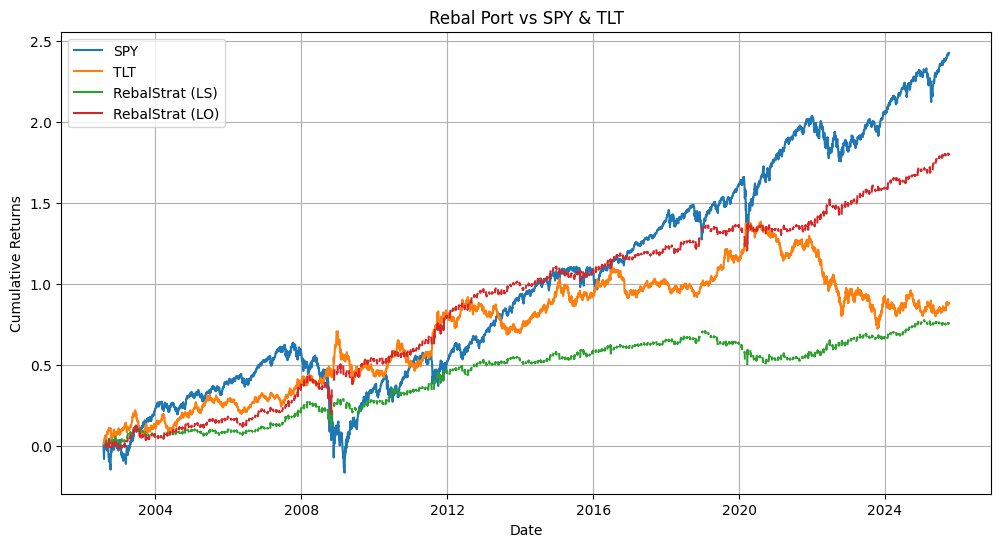

In [57]:
# --- Plotting ---
plt.figure(figsize=(12,6))
plt.plot(finalRet["date"], finalRet["cum_r_spy"], label="SPY")
plt.plot(finalRet["date"], finalRet["cum_r_tlt"], label="TLT")
plt.plot(finalRet["date"], finalRet["cum_r_strat_ls"], label="RebalStrat (LS)")
plt.plot(finalRet["date"], finalRet["cum_r_strat_lo"], label="RebalStrat (LO)")
plt.legend()
plt.title("Rebal Port vs SPY & TLT")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.grid(True)
plt.show()

In [58]:
# --- Compute Sharpe Ratios ---
sharpe = {
    "SPY": round(sharpe_ratio(finalRet["r_spy"].to_numpy()), 3),
    "TLT": round(sharpe_ratio(finalRet["r_tlt"].to_numpy()), 3),
    "Long-Short": round(sharpe_ratio(finalRet["r_strat_ls"].fill_null(0).to_numpy()), 3),
    "Long-Only": round(sharpe_ratio(finalRet["r_strat_lo"].fill_null(0).to_numpy()), 3),
}

sharpe

{'SPY': np.float64(0.648),
 'TLT': np.float64(0.336),
 'Long-Short': np.float64(0.516),
 'Long-Only': np.float64(0.889)}